In [1]:
### Code to read in h5 files as detailed in the first guidebook
# Import necessary packages
import sys

sys.path.append(r"C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts")
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import signal
import glob
import utide
plt.rcParams.update({'font.size': 14}) 

deployment_num = [1,2,3,4,5]
sensor_spot = ["S", "C", "E"]
# directory_initial_user_path = r"/Volumes/BOEM/"  # Katherine
# directory_initial_user_path = r"/Volumes/kanarde/BOEM/"  # Brooke
directory_initial_user_path = r"Z:/"  # Levi

def tidal_ellipse(u,v,t,constituents = ['M2'], sensor = "S0",dep = "1",plotter = True):
 
    coef = utide.solve(t, u, v, lat=33.9, method="ols", conf_int="linear", constit=constituents)

    #With coefficients, we can reconstruct the tidal signal and plot the ellipses
    out = utide.reconstruct(t, coef)

    # Extract the fitted velocities
    u_fit = out.u
    v_fit = out.v
    if plotter == True:
        # Plotting the ellipse
        plt.figure(figsize=(6, 6))
        plt.plot(v_fit,u_fit, label='Reconstructed Tidal Ellipse')
        plt.axhline(0, color='black', lw=1, ls='--')
        plt.axvline(0, color='black', lw=1, ls='--')
        plt.xlabel("East Velocity (m/s)")
        plt.ylabel("North Velocity (m/s)")
        plt.title(f"Tidal Ellipse for {constituents[0]} - sensor {sensor} - Deployment {dep}")
        plt.axis('equal') # Crucial for seeing the true shape of the ellipse
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    #Remove tidal ellipse from original signal to get residuals
    u_residual = u - u_fit
    v_residual = v - v_fit

    return coef, out, pd.DataFrame({
        "U_residual": u_residual,
        "V_residual": v_residual
    })


In [2]:
# Import bulkstats and create dictionary for each sensor
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            print(f"Processing {sensor_location}...")
            files = ["DepthAveragedFlowDirection",'WaveCelerity', "DepthAveragedCurrentVelocity","Time","DepthAveragedEastVelocity","DepthAveragedNorthVelocity","SignificantWaveHeight","MeanDirection1","MeanPeriod"]
            waves = {}
            for file in files:
                file_path = os.path.join(sensor_id, file)  # file path
                df = pd.read_hdf(file_path)  # read the file into a Pandas dataframe
                file_name = file.split(".")[0]  # file name
                print(file_name)
                waves[file_name] = df  # store dataframe
            globals()[f"waves_{sensor_location}_{dep}"] = waves

Processing S0...
DepthAveragedFlowDirection
WaveCelerity
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
SignificantWaveHeight
MeanDirection1
MeanPeriod
Processing S1...
DepthAveragedFlowDirection
WaveCelerity
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
SignificantWaveHeight
MeanDirection1
MeanPeriod
Processing E1...
DepthAveragedFlowDirection
WaveCelerity
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
SignificantWaveHeight
MeanDirection1
MeanPeriod
Processing S0...
DepthAveragedFlowDirection
WaveCelerity
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
SignificantWaveHeight
MeanDirection1
MeanPeriod
Processing S1...
DepthAveragedFlowDirection
WaveCelerity
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
SignificantWaveHeight
MeanDirection1
MeanPeriod
Processing E1...
DepthAveragedFlowDirect

In [3]:
#Transform vels into alongshoal and cross-shoal components
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1

            print(f"Processing {sensor_location}...")
            waves = globals()[f"waves_{sensor_location}_{dep}"]
            shoal_bearing = 156 
            # math radians not nautical
            theta = np.radians(90 -shoal_bearing) 
            
            u = waves["DepthAveragedEastVelocity"].values.squeeze()
            v = waves["DepthAveragedNorthVelocity"].values.squeeze()

            along_shore_vel = u * np.cos(theta) + v * np.sin(theta)
            cross_shore_vel = v * np.cos(theta) - u * np.sin(theta)

            waves["AlongShoreVelocity"] = along_shore_vel
            waves["CrossShoreVelocity"] = cross_shore_vel
            globals()[f"waves_{sensor_location}_{dep}"] = waves

Processing S0...
Processing S1...
Processing E1...
Processing S0...
Processing S1...
Processing E1...
Processing S0...
Processing C0...
Processing E0...
Processing S1...
Processing E1...
Processing S1...
Processing C0...


In [7]:
###Low pass filter at 48hours to get subtidal flows
# from spectral_sediment import lowpass_filter
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:# Extract S0, S1, E1
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            print(f"Processing {sensor_location}...")
            waves = globals()[f"waves_{sensor_location}_{dep}"]
            for vel in ["AlongShoreVelocity", "CrossShoreVelocity"]:
                # filtered_vel = lowpass_filter(waves[vel], cutoff=1/48, fs=1)  # fs=1 for hourly data
                # waves[f"{vel}_Subtidal"] = filtered_vel
                coef, out, residuals = tidal_ellipse(waves["DepthAveragedEastVelocity"].values.squeeze(), 
                                              waves["DepthAveragedNorthVelocity"].values.squeeze(), 
                                              waves["Time"].values.squeeze(), 
                                              constituents=['M2'], 
                                              sensor=sensor_location, 
                                              dep=dep,
                                              plotter=False)
            waves['Tide_Residual_u'] = coef.umean
            waves['Tide_Residual_v'] = coef.vmean
            waves["AlongShoreVelocity_Residual"] = np.nanmean(waves['AlongShoreVelocity']) #Positive cross-shore velocity is to the 
            waves["CrossShoreVelocity_Residual"] = np.nanmean(waves['CrossShoreVelocity'])
            waves['MajorTidalAxis'] = coef['Lsmaj']
            waves['MinorTidalAxis'] = coef['Lsmin']
            globals()[f"waves_{sensor_location}_{dep}"] = waves

# plt.plot(waves_S1_2["CrossShoreVelocity_Subtidal"], label="S1 Cross Shore Subtidal Velocity", linestyle='--')
# plt.plot(waves_E1_2["CrossShoreVelocity_Subtidal"], label="E1 Cross Shore Subtidal Velocity")
# plt.plot(waves_S0_2["CrossShoreVelocity_Subtidal"], label="S0 Cross Shore Subtidal Velocity", linestyle='--')
# plt.xlabel("Time (hrs)")
# plt.ylabel("Velocity (m/s)")
# plt.title("Cross-shore Velocities for Locations - Deployment 2")
# plt.legend()
# plt.show()

Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.

['Z:/deployment_1/BulkStats\\S0_103080', 'Z:/deployment_1/BulkStats\\S1_101418']
Processing S0...
S0
Processing S1...
S1
[]
['Z:/deployment_1/BulkStats\\E1_103071']
Processing E1...
E1
['Z:/deployment_2/BulkStats\\S0_103080', 'Z:/deployment_2/BulkStats\\S1_101418']
Processing S0...
S0
Processing S1...
S1
[]
['Z:/deployment_2/BulkStats\\E1_103071']
Processing E1...
E1
['Z:/deployment_3/BulkStats\\S0_101418']
Processing S0...
S0
['Z:/deployment_3/BulkStats\\C0_103071']
Processing C0...
C0
['Z:/deployment_3/BulkStats\\E0_103080']
Processing E0...
E0
['Z:/deployment_4/BulkStats\\S1_103080']
Processing S1...
S1
[]
['Z:/deployment_4/BulkStats\\E1_103071']
Processing E1...
E1
['Z:/deployment_5/BulkStats\\S1_101481']
Processing S1...
S1
['Z:/deployment_5/BulkStats\\C0_107730']
Processing C0...
C0
[]


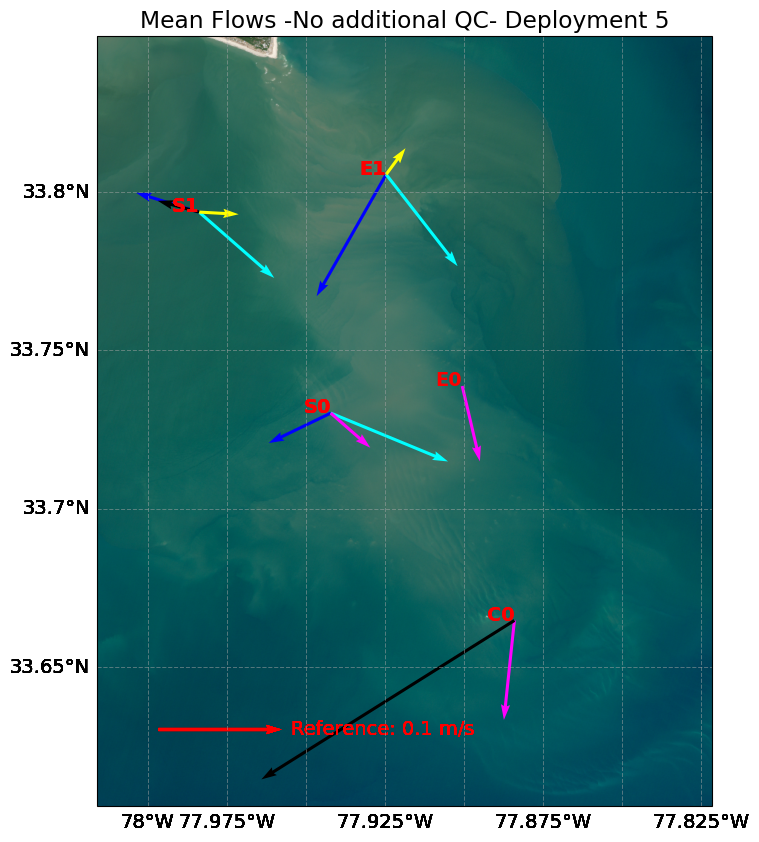

In [8]:
# Convert dep to string to match filename parsing
import rasterio
import cartopy.crs as ccrs

filepath = r"z:\deployment_2\2024-11-25_16bitTiff.tiff"
filepath  = r"z:\deployment_3\2025-02-28-16bitTiff.tiff"

src = rasterio.open(filepath)
img16 = src.read()
# Basic normalization for 8-bit display
img8 = ((img16 - np.min(img16)) / (np.max(img16) - np.min(img16)) * 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})

extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
ax.imshow(
    img8.transpose(1, 2, 0),
    origin="upper",
    extent=extent, 
    transform=ccrs.PlateCarree()
)

lander_coords = {
"S0": (-77.942100, 33.730200),
"S1": (-77.983700, 33.793700),
"C0": (-77.884083, 33.664683),
"E0": (-77.900567, 33.738750),
"E1": (-77.924600, 33.805600) # 33.805593 -77.924593$
}

deployment_colors = {
    1: 'blue',
    2: 'cyan',
    3: 'magenta',
    4: 'yellow',
    5: 'black',
}

for dep in deployment_num:
    dep_color = deployment_colors.get(dep, 'white')
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        print(sensor_ids)
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            data = globals()[f"waves_{sensor_location}_{dep}"]
            print(f"Processing {sensor_location}...")

            # Extract velocities
            u = np.nanmean(data['DepthAveragedEastVelocity'])
            v = np.nanmean(data['DepthAveragedNorthVelocity'])
            # Get coords from dictionary, default to S0 if not found

            sensor = str(sensor_location)
            print(sensor)
            lon, lat = lander_coords.get(sensor, lander_coords["S0"])

            q = ax.quiver(
                lon, lat, u, v,
                transform=ccrs.PlateCarree(),
                color=dep_color, 
                scale=0.5,      # Adjust based on current speeds
                width=0.005
            )
            qk = ax.quiverkey(q, 
                X=0.3, Y=0.1, # Position on the plot
                U=0.1,        # The length of the reference arrow (e.g., 0.01 m/s)
                label='Reference: 0.1 m/s', 
                labelpos='E',
                color='red',
                labelcolor='red'
                )
        
        
            # Add a label for the lander
            ax.text(lon, lat, sensor_location, transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')


            # Gridlines and Labels
            gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.05)
            gl.top_labels = False
            gl.right_labels = False
        plt.title(f"Mean Flows -No additional QC- Deployment {dep}")

solve: matrix prep ... solution ... done.
prep/calcs ... done.


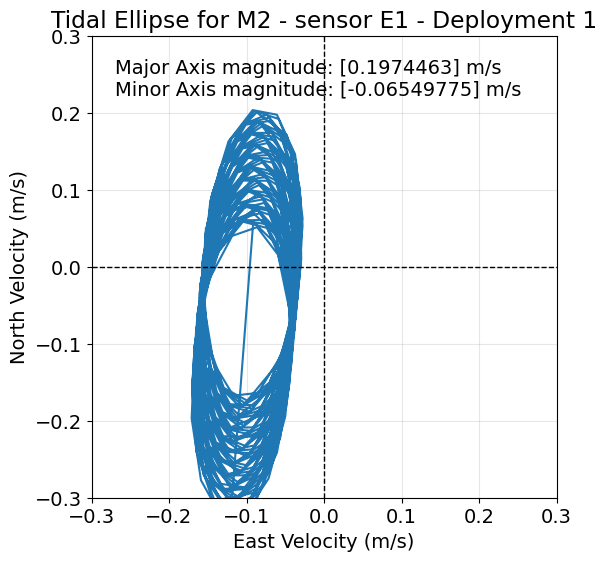

solve: matrix prep ... solution ... done.
prep/calcs ... done.


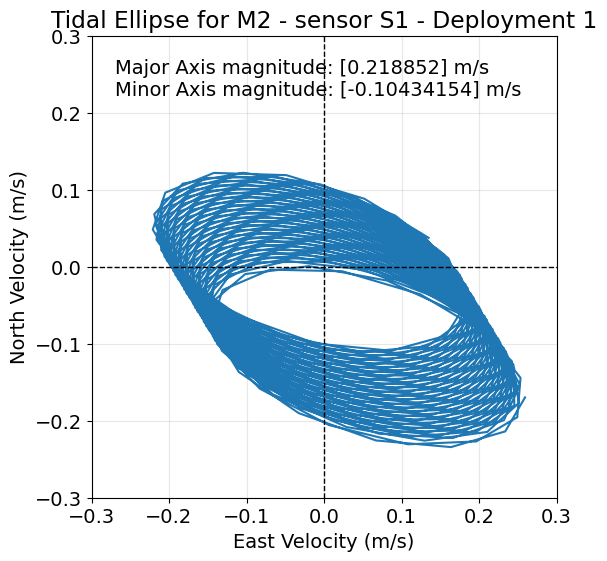

solve: matrix prep ... solution ... done.
prep/calcs ... done.


C:\Users\lwlav\AppData\Local\Temp\ipykernel_28148\4036750750.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


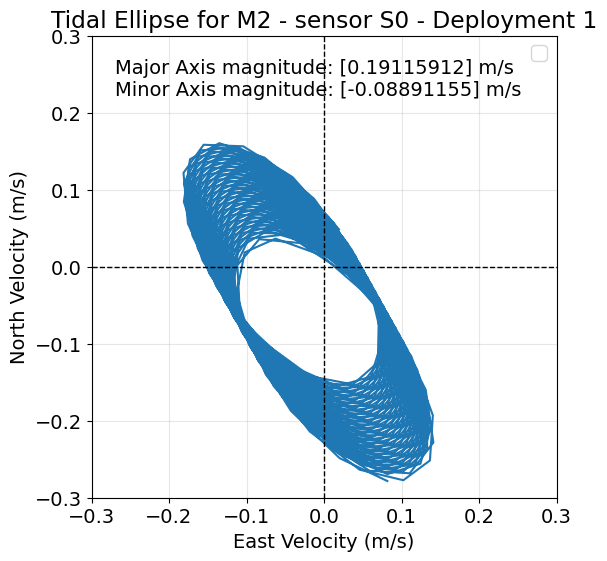

In [ ]:
u = waves_E1_1["DepthAveragedEastVelocity"].values.squeeze()
v = waves_E1_1["DepthAveragedNorthVelocity"].values.squeeze()

coef, out, resid = tidal_ellipse(u, v, waves_E1_1["Time"].values.squeeze(), constituents=["M2"], sensor="E1", dep=dep,plotter=False)


u_fit = out.u
v_fit = out.v
maj = coef['Lsmaj']
mini = coef['Lsmin']


plt.figure(figsize=(6, 6))
plt.plot(v_fit,u_fit)
plt.axhline(0, color='black', lw=1, ls='--')
plt.axvline(0, color='black', lw=1, ls='--')
plt.xlabel("East Velocity (m/s)")
plt.ylabel("North Velocity (m/s)")
plt.title(f"Tidal Ellipse for {'M2'} - sensor {sensor} - Deployment 1")
plt.xlim(-0.3, 0.3)
plt.ylim(-0.3, 0.3)
plt.grid(True, alpha=0.3)
plt.text(0.05, 0.95, f'Major Axis magnitude: {maj} m/s\nMinor Axis magnitude: {mini} m/s', transform=plt.gca().transAxes, verticalalignment='top')
plt.show()

u = waves_S1_1["DepthAveragedEastVelocity"].values.squeeze()
v = waves_S1_1["DepthAveragedNorthVelocity"].values.squeeze()
coef, out, resid = tidal_ellipse(u, v, waves_S1_1["Time"].values.squeeze(), constituents=["M2"], sensor="S1", dep=dep,plotter=False)

u_fit = out.u
v_fit = out.v
maj = coef['Lsmaj']
mini = coef['Lsmin']

plt.figure(figsize=(6, 6))
plt.plot(v_fit,u_fit)
plt.axhline(0, color='black', lw=1, ls='--')
plt.axvline(0, color='black', lw=1, ls='--')
plt.xlabel("East Velocity (m/s)")
plt.ylabel("North Velocity (m/s)")
plt.title(f"Tidal Ellipse for {'M2'} - sensor S1 - Deployment 1")
plt.xlim(-0.3, 0.3)
plt.ylim(-0.3, 0.3)
plt.grid(True, alpha=0.3)
plt.text(0.05, 0.95, f'Major Axis magnitude: {maj} m/s\nMinor Axis magnitude: {mini} m/s', transform=plt.gca().transAxes, verticalalignment='top')
plt.show()

u = waves_S0_1["DepthAveragedEastVelocity"].values.squeeze()
v = waves_S0_1["DepthAveragedNorthVelocity"].values.squeeze()
coef, out, resid = tidal_ellipse(u, v, waves_S0_1["Time"].values.squeeze(), constituents=["M2"], sensor="S0", dep=dep,plotter=False)

u_fit = out.u
v_fit = out.v
maj = coef['Lsmaj']
mini = coef['Lsmin']

plt.figure(figsize=(6, 6))
plt.plot(v_fit,u_fit)
plt.axhline(0, color='black', lw=1, ls='--')
plt.axvline(0, color='black', lw=1, ls='--')
plt.xlabel("East Velocity (m/s)")
plt.ylabel("North Velocity (m/s)")
plt.title(f"Tidal Ellipse for {'M2'} - sensor S0 - Deployment 1")
plt.xlim(-0.3, 0.3)
plt.ylim(-0.3, 0.3)
plt.grid(True, alpha=0.3)
plt.legend()
plt.text(0.05, 0.95, f'Major Axis magnitude: {maj} m/s\nMinor Axis magnitude: {mini} m/s', transform=plt.gca().transAxes, verticalalignment='top')
plt.show()

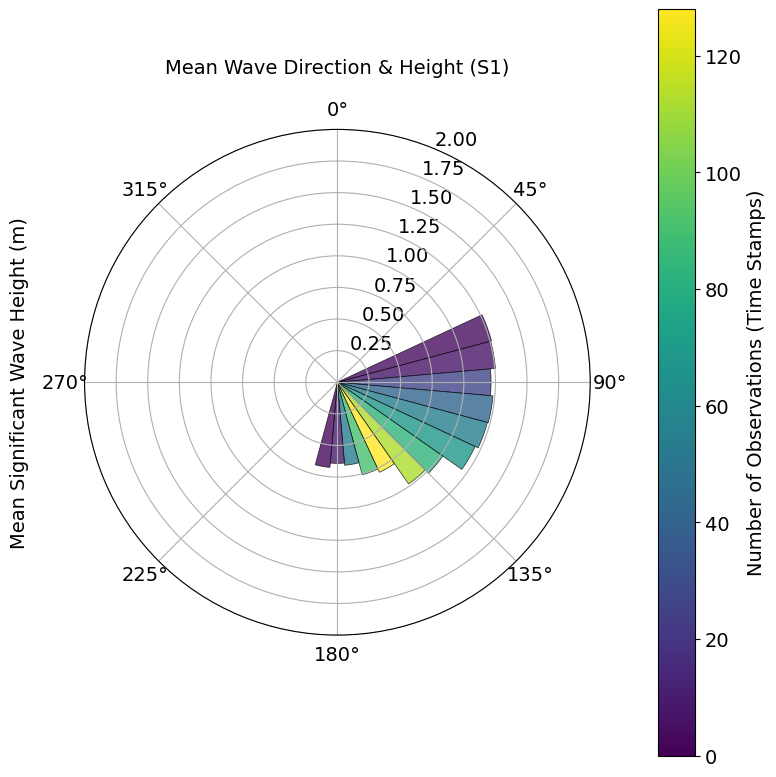

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

heights = waves_S1_1['SignificantWaveHeight'].values.squeeze()
dirs = waves_S1_1["MeanDirection1"].values.squeeze()

# We'll use 10-degree bins (36 bins total)
bins = np.arange(-5, 365, 10)
direction_wrapped = (dirs + 5) % 360 - 5
bin_indices = np.digitize(direction_wrapped, bins) - 1

# Initialize arrays for the 36 bins
bin_height_avg = np.zeros(36)
bin_counts = np.zeros(36)

for i in range(36):
    mask = (bin_indices == i)
    if np.any(mask):
        # Average height of waves in this direction bin
        bin_height_avg[i] = np.nanmean(heights[mask])
        # Count how many times waves came from this direction
        bin_counts[i] = np.sum(mask)

# Prepare polar coordinates
bin_theta = np.deg2rad((bins[:-1] + bins[1:]) / 2)
bin_width = np.deg2rad(10)

# Normalize counts for color mapping (Frequency of occurrence)
norm = plt.Normalize(bin_counts.min(), bin_counts.max())
cmap = plt.get_cmap("viridis")
colors = cmap(norm(bin_counts))

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 8))

# Bar length = Avg Significant Height; Color = Frequency of occurrence
bars = ax.bar(bin_theta, bin_height_avg, width=bin_width, bottom=0, 
              color=colors, alpha=0.8, edgecolor='k', linewidth=0.5)

# Formatting
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_title("Mean Wave Direction & Height (S1)", pad=20, fontsize=14)

# Radial axis represents Wave Height
ax.set_ylabel("Mean Significant Wave Height (m)", labelpad=40)

# Colorbar for Frequency
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.1)
cbar.set_label("Number of Observations (Time Stamps)")
ax.set_rlim(0, 2)


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv(r'C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts\OLD\CORMP_SouthShoal_USACE41108_2024.txt', sep='\s+')  # Assuming whitespace-delimited
print(df.keys())

Index(['YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'WVHT', 'DPD',
       'APD', 'MWD', 'PRES', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE'],
      dtype='str')


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\lwlav\AppData\Local\Temp\ipykernel_28148\2304684154.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(r'C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts\OLD\CORMP_SouthShoal_USACE41108_2024.txt', sep='\s+')  # Assuming whitespace-delimited


C:\Users\lwlav\AppData\Local\Temp\ipykernel_28148\35750513.py:33: RuntimeWarning: Mean of empty slice
  bin_height_avg[i] = np.nanmean(heights[mask])


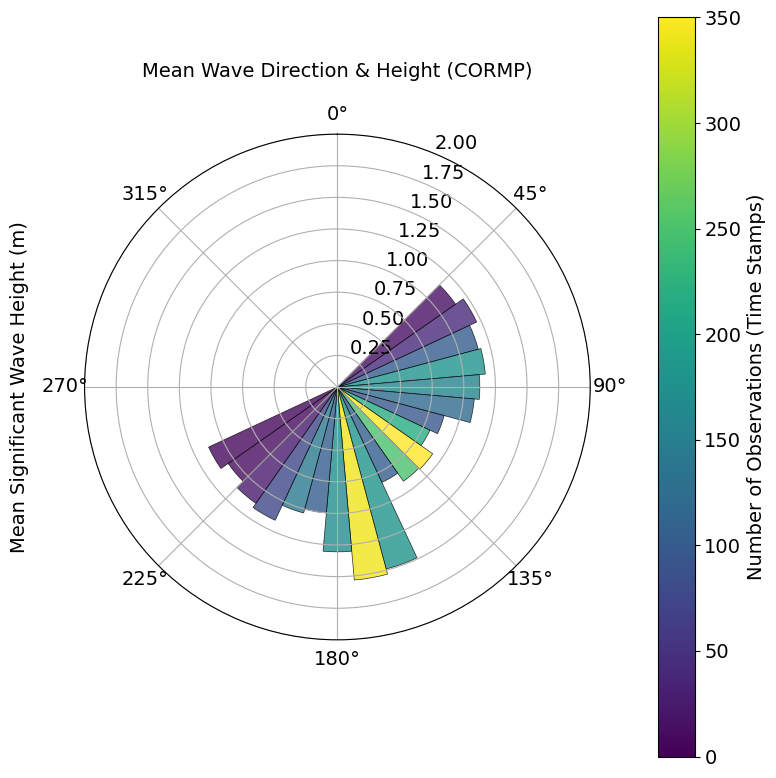

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extraction
heights = df['WVHT'].values.squeeze().copy()
dirs = df["MWD"].values.squeeze().copy()
# Assuming months exists in this dataframe as well
months = df['MM'].values.squeeze().copy() 

# Create a single boolean array for the months you want
month_mask = (months >= 8) & (months <= 9)

# Apply mask to everything at once
heights = heights[month_mask]
dirs = dirs[month_mask]

# Filter out unrealistic wave heights (99 is missing data)
heights[heights >= 90] = np.nan 

# 10-degree bins logic
bins = np.arange(-5, 365, 10)
direction_wrapped = (dirs + 5) % 360 - 5
bin_indices = np.digitize(direction_wrapped, bins) - 1

# Initialize arrays
bin_height_avg = np.zeros(36)
bin_counts = np.zeros(36)

for i in range(36):
    mask = (bin_indices == i)
    if np.any(mask):
        # We use nanmean to ignore the missing values we set earlier
        bin_height_avg[i] = np.nanmean(heights[mask])
        bin_counts[i] = np.sum(mask)

# CRITICAL: Convert any remaining NaNs to 0 to prevent the 'vertices' error
bin_height_avg = np.nan_to_num(bin_height_avg)

# Prepare polar coordinates
bin_theta = np.deg2rad((bins[:-1] + bins[1:]) / 2)
bin_width = np.deg2rad(10)

# Normalize colors
norm = plt.Normalize(bin_counts.min(), bin_counts.max())
cmap = plt.get_cmap("viridis")
colors = cmap(norm(bin_counts))

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 8))

# Plotting
bars = ax.bar(bin_theta, bin_height_avg, width=bin_width, bottom=0, 
              color=colors, alpha=0.8, edgecolor='k', linewidth=0.5)

# Formatting
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rlim(0, 2)
ax.set_title("Mean Wave Direction & Height (CORMP)", pad=20, fontsize=14)
ax.set_ylabel("Mean Significant Wave Height (m)", labelpad=40)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.1)
cbar.set_label("Number of Observations (Time Stamps)")

plt.tight_layout()
plt.show()

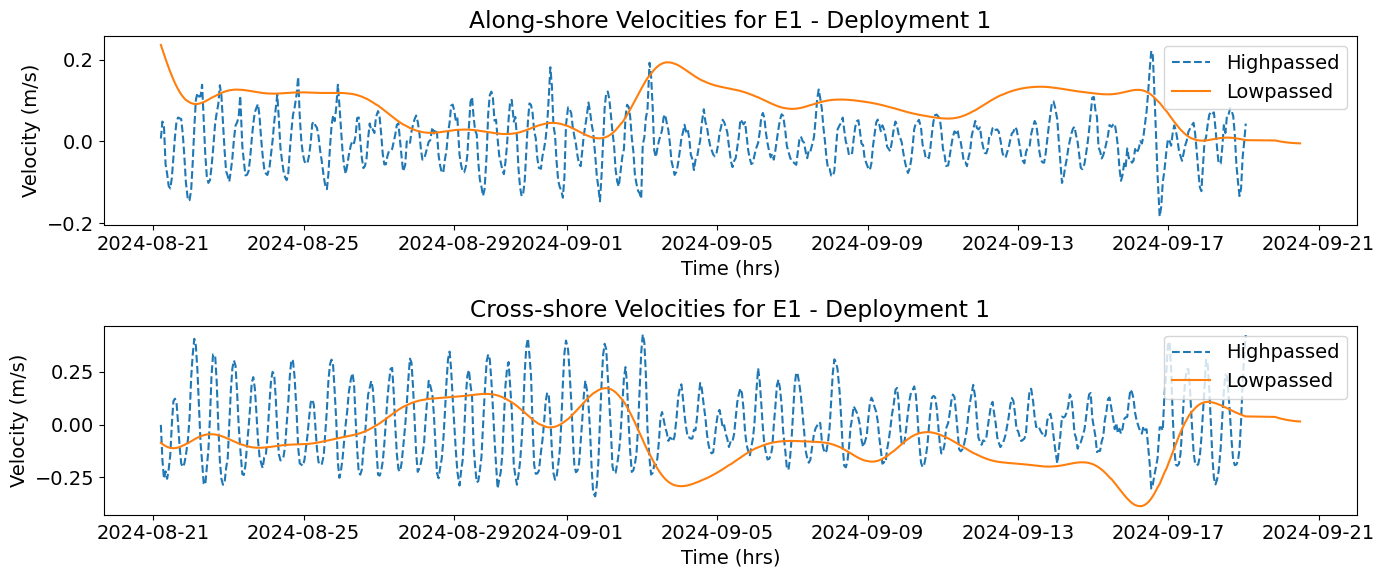

In [ ]:
#Compare average flow from highpass and lowpass 
long_along = waves_E1_1["AlongShoreVelocity_Subtidal"]
long_cross = waves_E1_1["CrossShoreVelocity_Subtidal"]

short_along = waves_E1_1["AlongShoreVelocity"] - waves_E1_1["AlongShoreVelocity_Subtidal"]
short_cross = waves_E1_1["CrossShoreVelocity"] - waves_E1_1["CrossShoreVelocity_Subtidal"]

x = waves_E1_1['Time'].values.squeeze()

plt.subplots(2, 1, figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(x,short_along, label="Highpassed", linestyle='--')
plt.plot(x,long_along, label="Lowpassed", linestyle='-')
plt.xlabel("Time (hrs)") 
plt.ylabel("Velocity (m/s)")
plt.title("Along-shore Velocities for E1 - Deployment 1")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(x, short_cross, label="Highpassed", linestyle='--')
plt.plot(x, long_cross, label="Lowpassed", linestyle='-')
plt.xlabel("Time (hrs)") 
plt.ylabel("Velocity (m/s)")
plt.title("Cross-shore Velocities for E1 - Deployment 1")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import tabulate

#Create a few tables summarizing tidal spatial and temporal variability across deployments and sensors.
#South over East per deployment 

SvE = [["Deployment", 1,2,3,4],
        ["Locations", "S1/E1", "S1/E1", "S0/E0", "S1/E1"],
        ["Major Axis Difference (%)", (waves_S1_1["MajorTidalAxis"]/waves_E1_1["MajorTidalAxis"])[0],
         (waves_S1_2["MajorTidalAxis"]/waves_E1_2["MajorTidalAxis"])[0],
         (waves_S0_3["MajorTidalAxis"]/waves_E0_3["MajorTidalAxis"])[0],
         (waves_S1_4["MajorTidalAxis"]/waves_E1_4["MajorTidalAxis"])[0]],
        ["Minor Axis Difference (%)", (waves_S1_1["MinorTidalAxis"]/waves_E1_1["MinorTidalAxis"])[0],
         (waves_S1_2["MinorTidalAxis"]/waves_E1_2["MinorTidalAxis"])[0],
         (waves_S0_3["MinorTidalAxis"]/waves_E0_3["MinorTidalAxis"])[0],
         (waves_S1_4["MinorTidalAxis"]/waves_E1_4["MinorTidalAxis"])[0]]]

print(tabulate.tabulate(SvE, headers="firstrow", tablefmt="double_grid"))

#Seasonal Variability of Tidal Ellipse 
Seasonal = [["Season", "Summer-->Fall", "Fall-->Winter","Winter-->Spring", "Spring-->Summer"],
            ["S0", waves_S0_1['MajorTidalAxis'][0], waves_S0_2['MajorTidalAxis'][0], waves_S0_3['MajorTidalAxis'][0], 'N/A'],
            ["S1", np.mean([waves_S1_1['MajorTidalAxis'][0], waves_S1_5['MajorTidalAxis'][0]]), waves_S1_2['MajorTidalAxis'][0], 'N/A', waves_S1_4['MajorTidalAxis'][0]],
            ["E0", 'N/A', 'N/A', waves_E0_3['MajorTidalAxis'][0],'N/A', 'N/A'],
            ["E1", waves_E1_1['MajorTidalAxis'][0], waves_E1_2['MajorTidalAxis'][0],'N/A',waves_E1_4['MajorTidalAxis'][0]],
            ["C0", waves_C0_5['MajorTidalAxis'][0],'N/A',waves_C0_3['MajorTidalAxis'][0],'N/A']]

print(tabulate.tabulate(Seasonal, headers="firstrow", tablefmt="double_grid"))

#Backscatter variability analysis

╔═══════════════════════════╦════════════════════╦════════════════════╦════════════════════╦════════════════════╗
║ Deployment                ║ 1                  ║ 2                  ║ 3                  ║ 4                  ║
╠═══════════════════════════╬════════════════════╬════════════════════╬════════════════════╬════════════════════╣
║ Locations                 ║ S1/E1              ║ S1/E1              ║ S0/E0              ║ S1/E1              ║
╠═══════════════════════════╬════════════════════╬════════════════════╬════════════════════╬════════════════════╣
║ Major Axis Difference (%) ║ 1.1084127934457157 ║ 1.1334382692986034 ║ 1.5421896377291395 ║ 1.6098973632514129 ║
╠═══════════════════════════╬════════════════════╬════════════════════╬════════════════════╬════════════════════╣
║ Minor Axis Difference (%) ║ 1.5930553087035004 ║ 1.6849107230643687 ║ 1.652481965598388  ║ 1.9166468621366235 ║
╚═══════════════════════════╩════════════════════╩════════════════════╩═════════════════